In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis
import deepssfp.dataloader

In [2]:
path = 'D:/MRI/2024_Krithika_KneeStudy'
filters = [
    'HV1_lk_r1', 'HV2_lk_r1', 'HV3_lk_r1', 'HV4_lk_r1', 'HV5_lk_r1', 'HV6_lk_r1', 'HV7_lk_r1', 'HV8_lk_r1',
    'HV1_rk_r1', 'HV2_rk_r1', 'HV3_rk_r1', 'HV4_rk_r1', 'HV5_rk_r1', 'HV6_rk_r1', 'HV7_rk_r1', 'HV8_rk_r1',]

dataset = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters)

100%|██████████| 4/4 [00:12<00:00,  3.14s/it]


(1280, 416, 416, 4)
Dataset loaded: (1280, 416, 416, 4)
Memory size: 7.08837376 GB


In [3]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="knee_study"


===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/knee_study_syntheticbanding
Dataset path: D:/DeepSSFP/knee_study_dataset.npy
Data shape: (1280, 416, 416, 4)
Using same scaler for SyntheticBanding mode
Training data shape: (1024, 416, 416, 4), (1024, 416, 416, 4)
Input scaler stats: mean=-0.0248, std=25.4826
Output scaler stats: mean=-0.0248, std=25.4826
Selected indices: [  0 205 145]
Figure size: (8, 6)


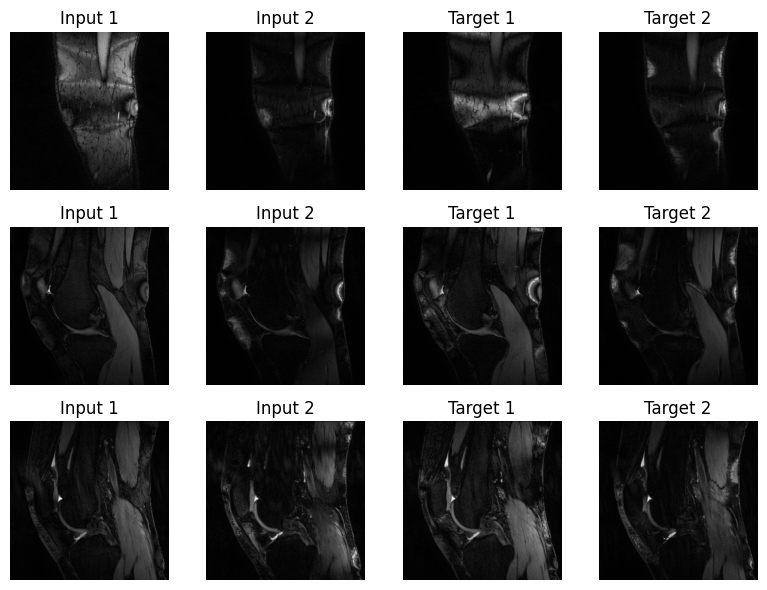

2025-04-07 17:31:43,524 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/knee_study_syntheticbanding



Loading pre-trained model...


2025-04-07 17:31:47,922 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/knee_study_syntheticbanding.keras
2025-04-07 17:31:47,923 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/knee_study_syntheticbanding_history.npz
2025-04-07 17:31:49,167 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/knee_study_syntheticbanding_training_history.png


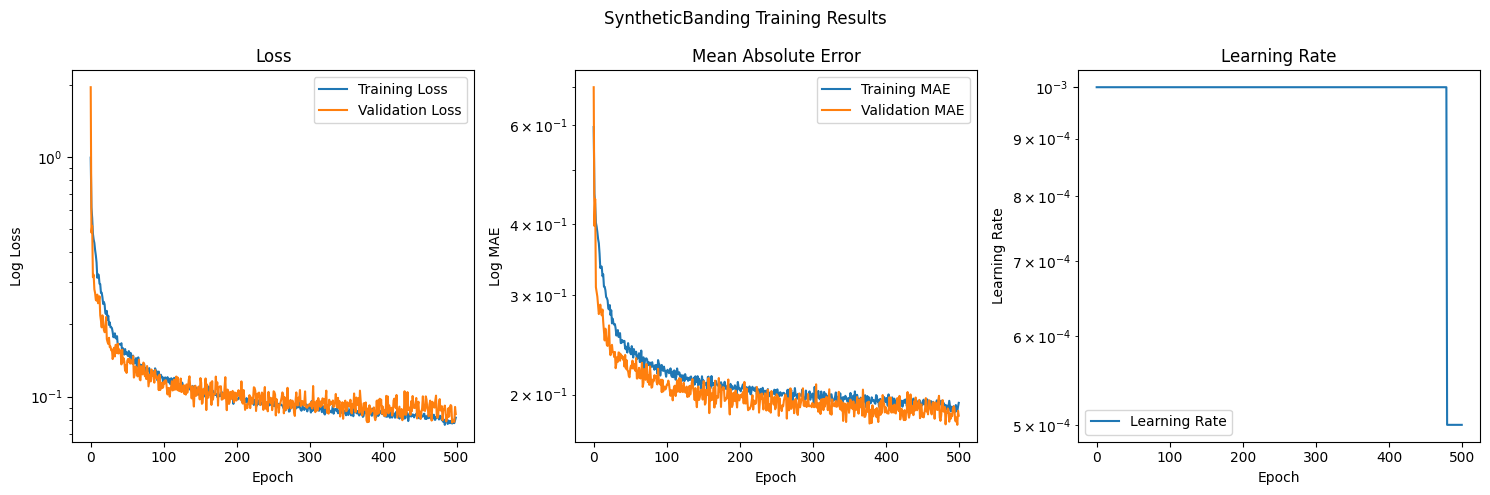

2025-04-07 17:31:51,822 - DeepSSFP - INFO - Making predictions on data with shape (256, 416, 416, 4)
2025-04-07 17:32:01,623 - DeepSSFP - INFO - Predictions complete. Output shape: (256, 416, 416, 4)


Selected indices: [ 77 171]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/knee_study_syntheticbanding_prediction_results.png


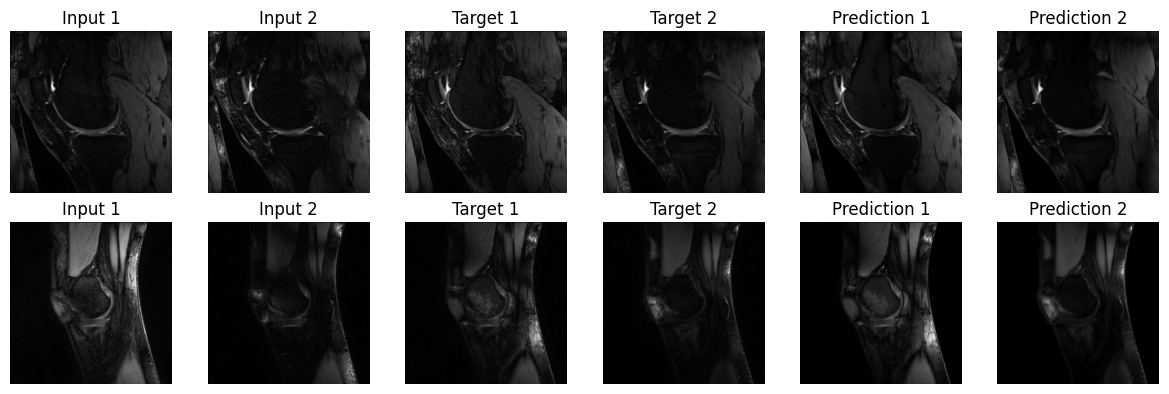

real/imag pairs -> complex


../..\deepssfp\recon.py:142: RuntimeWarning: invalid value encountered in divide
  M = ((x1*y3 - x3*y1)*(Is[1, ...] - Is[3, ...]) - (


real/imag pairs -> complex
Target shape: (256, 416, 416), Prediction shape: (256, 416, 416)


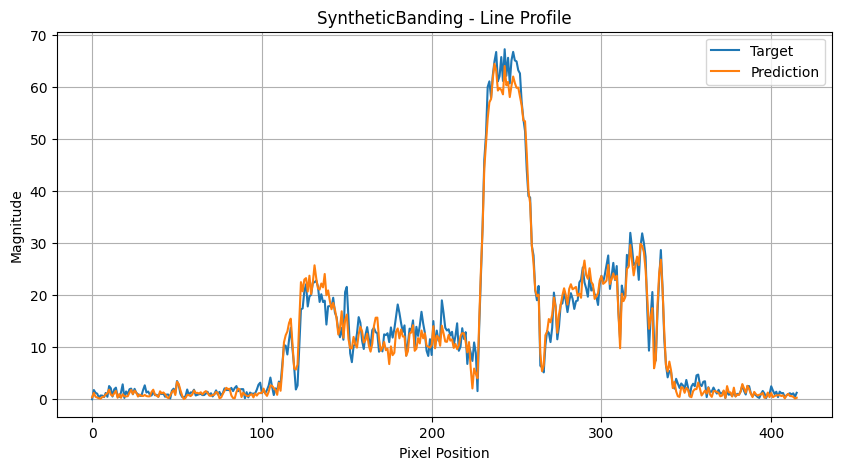


Evaluating band reduction...
Target shape: (256, 416, 416)
Prediction shape: (256, 416, 416)
Segmentation shape: (256, 416, 416)
Unique segmentation IDs: [0 1]
IDs to plot: [1]
Training history plot saved to D:/DeepSSFP/knee_study_syntheticbanding_band_metrics_scatter


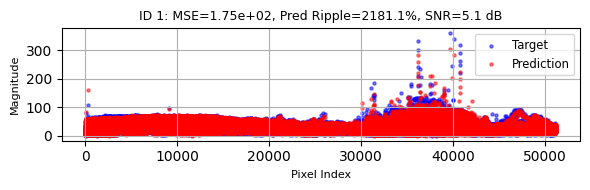

Training history plot saved to D:/DeepSSFP/knee_study_syntheticbanding_band_metrics


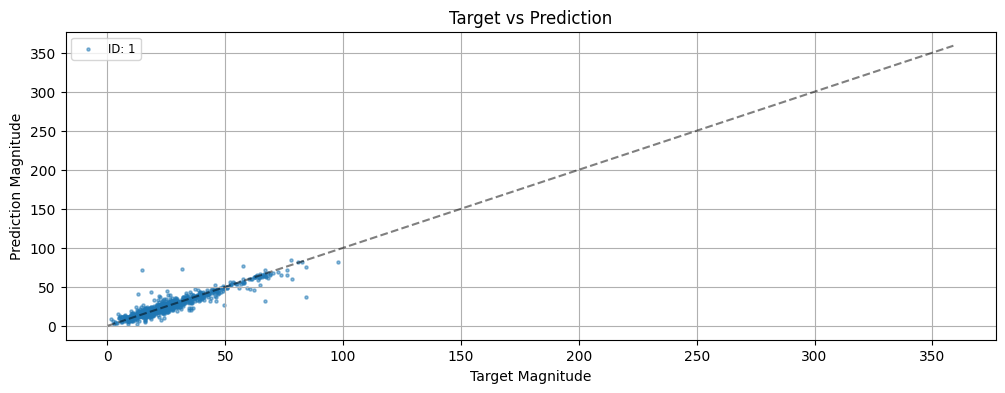


Metrics by Segment ID (averaged across all samples):
ID 1: MSE=1.75e+02, MAE=3.29e+00, Pred Min=0.2191, Pred Max=686.3687, Pred Ripple=2181.11%, Pred SNR=5.1 dB, Target Min=0.2101, Target Max=1021.6989, Target Ripple=3098.73%, Samples=256, Pixels=51252

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: nan
  MAE: nan
  PSNR: nan
  SSIM: nan
  NRMSE: nan

SEGMENT_0:
  MSE: nan
  MAE: nan
  PSNR: nan
  SSIM: nan
  NRMSE: nan

SEGMENT_1:
  MSE: 174.832056
  MAE: 3.287966
  PSNR: 27.023206
  SSIM: nan
  NRMSE: 0.214599
Metrics saved to D:/DeepSSFP/knee_study_syntheticbanding_all_metrics.npy


In [4]:
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=False,
    custom_dataset=dataset,
    save_dataset=False,
)